Total de localidades (N): 6334
Media poblacional (mu): 6.6900 años
Desviación estándar poblacional (sigma): 1.9088 años

EJERCICIO 1: PRUEBA t DE STUDENT (DOS COLAS, n < 30)


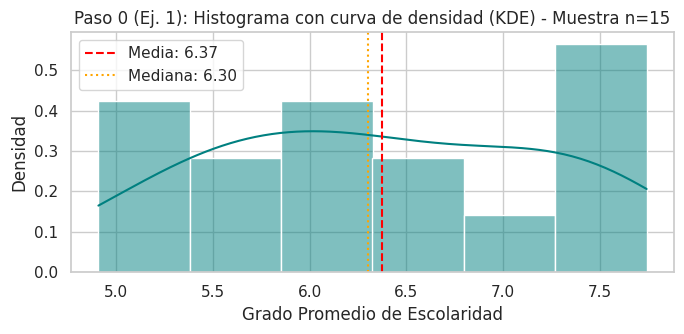

[Paso 0. Evaluación visual del supuesto de normalidad]
- ¿Media (6.37) y mediana (6.30) similares?: Sí, son consistentes.
- ¿Valores muy atípicos?: No se observan en el gráfico.
- ¿Es razonable asumir normalidad?: Sí, el histograma y el KDE muestran una distribución acampanada aceptable.

[Paso 1. Hipótesis]
H0: mu = 6.69
Ha: mu != 6.69

[Paso 2. Nivel de significancia (alpha)]: 0.05

[Paso 3. Identificación del estadístico]
Paso 3.1 Estadístico de prueba: t de Student (n < 30 y desviación poblacional desconocida)
Paso 3.2 Grados de libertad: 14
Paso 3.3 Tipo de prueba: Dos colas (bilateral)

[Paso 4. Cálculos]
Paso 4.1 Valor crítico: ±2.1448
  * Media muestral (x̄): 6.3727
  * Desviación estándar muestral (s): 0.8789
  * Tamaño de muestra (n): 15
Paso 4.2 Valor de prueba (t calculado): -1.3984



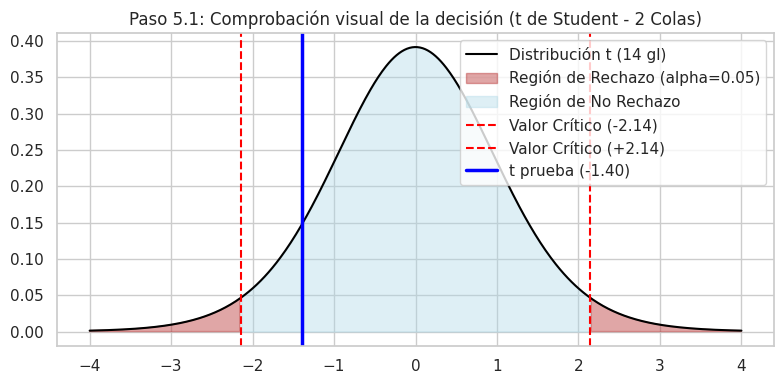

[Paso 5. Decisión e Interpretación]
Paso 5.2 Decisión: H0 no se rechaza (El valor de prueba -1.3984 está dentro de la región de aceptación).
Paso 5.2 Interpretación: Con un 95% de seguridad, aún no hay evidencia que demuestre que el promedio de escolaridad sea distinto a 6.69 años.

[Paso 6. Tipo de error que podría cometerse]
Paso 6.1 Tipo de error: Error Tipo II (Falso negativo).
Paso 6.2 Significado: No rechazar H0 cuando en realidad es falsa.
Paso 6.3 Interpretación: Asumir que la escolaridad no difiere de 6.69 cuando en la realidad sí ha cambiado.

EJERCICIO 2: PRUEBA Z (COLA DERECHA, n >= 30, SIGMA CONOCIDA)


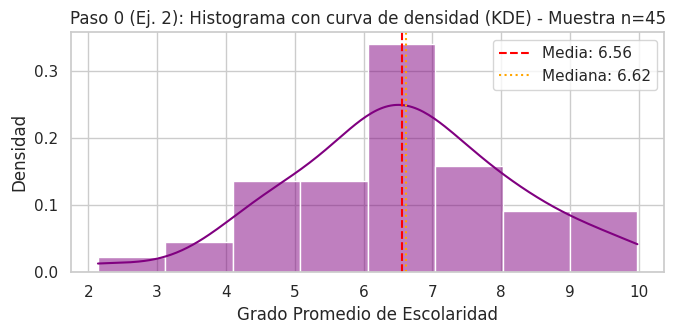

[Paso 0. Evaluación visual del supuesto de normalidad]
- ¿Media (6.56) y mediana (6.62) similares?: Bastante próximas.
- Teorema del Límite Central: Al ser n >= 30, la media muestral tiende a comportarse de forma normal.

[Paso 1. Hipótesis]
H0: mu <= 6.0
Ha: mu > 6.0

[Paso 2. Nivel de significancia (alpha)]: 0.05

[Paso 3. Identificación del estadístico]
Paso 3.1 Estadístico de prueba: Z Normal (n >= 30 y desviación estándar poblacional conocida)
Paso 3.2 Grados de libertad: N/A (no aplica para Z)
Paso 3.3 Tipo de prueba: Cola derecha

[Paso 4. Cálculos]
Paso 4.1 Valor crítico: 1.6449
  * Media muestral (x̄): 6.5649
  * Desviación estándar poblacional (sigma): 1.9088
  * Tamaño de muestra (n): 45
Paso 4.2 Valor de prueba (Z calculado): 1.9852



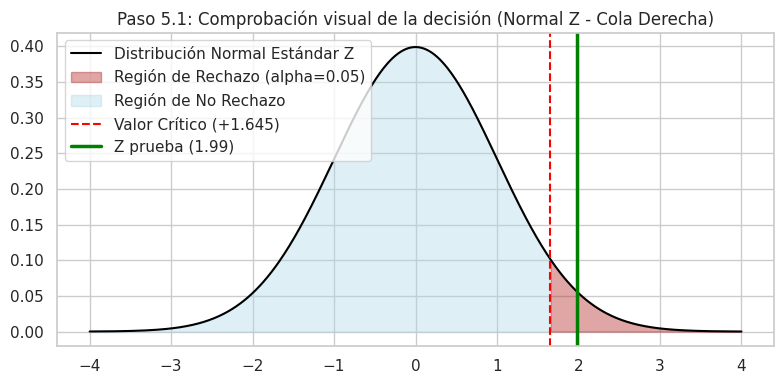

[Paso 5. Decisión e Interpretación]
Paso 5.2 Decisión: H0 se rechaza (El valor 1.9852 es >= al valor crítico de 1.6449).
Paso 5.2 Interpretación: Con un 95% de seguridad, se puede concluir que el grado promedio de escolaridad es superior a 6.0 años.

[Paso 6. Tipo de error que podría cometerse]
Paso 6.1 Tipo de error: Error Tipo I (Falso positivo).
Paso 6.2 Significado: Rechazar H0 cuando en realidad es verdadera.
Paso 6.3 Interpretación: Existe un 5% de probabilidad de afirmar erróneamente que la escolaridad es mayor a 6.0 cuando en realidad es menor o igual.


In [3]:
# ==============================================================================
# ACTIVIDAD PRÁCTICA: PRUEBAS DE HIPÓTESIS CON GRAPROES JALISCO
# Estructura idéntica al flujo de trabajo del Excel (Pasos 0 al 6)
# ==============================================================================

# ------------------------------------------------------------------------------
# 1. IMPORTACIÓN DE LIBRERÍAS
# ------------------------------------------------------------------------------
# Pandas: manipulación de la base de datos y extracción de muestras.
import pandas as pd
# NumPy: operaciones numéricas vectorizadas y raíz cuadrada.
import numpy as np
# Matplotlib y Seaborn: graficación del histograma con KDE y curvas de decisión.
import matplotlib.pyplot as plt
import seaborn as sns
# SciPy Stats: cálculo de cuantiles (valores críticos) y distribuciones t y normal.
import scipy.stats as stats

# Configuración estética general de las gráficas
sns.set_theme(style="whitegrid")

# ------------------------------------------------------------------------------
# 2. CARGA DE LA BASE DE DATOS Y PARÁMETROS GENERALES
# ------------------------------------------------------------------------------
# Lectura del archivo de datos en formato Excel/CSV.
df = pd.read_excel('GRAPROES_JAL_LOC.csv.xlsx')

# Limpieza básica: seleccionar la columna de interés y descartar valores nulos.
graproes = df['GRAPROES'].dropna()

# Parámetros poblacionales de referencia para Jalisco (N = 6,334 localidades):
mu_estatal = graproes.mean()           # Media poblacional: 6.6900 años
sigma_estatal = graproes.std(ddof=0)   # Desviación estándar poblacional: 1.9088 años

print(f"Total de localidades (N): {len(graproes)}")
print(f"Media poblacional (mu): {mu_estatal:.4f} años")
print(f"Desviación estándar poblacional (sigma): {sigma_estatal:.4f} años\n")


# ==============================================================================
# EJERCICIO 1: PRUEBA t DE STUDENT (Muestra n < 30, Desviación Muestral 's')
# Análogo al Problema 1 del Excel (Rendimiento anual a 2 colas)
# ==============================================================================
print("=" * 80)
print("EJERCICIO 1: PRUEBA t DE STUDENT (DOS COLAS, n < 30)")
print("=" * 80)

# Muestra de n = 15 localidades (fijamos semilla para reproducibilidad)
n1 = 15
m1 = graproes.sample(n=n1, random_state=42).reset_index(drop=True)

# ------------------------------------------------------------------------------
# PASO 0: EVALUAR SUPUESTO DE NORMALIDAD (Inspección Gráfica y Medidas)
# ------------------------------------------------------------------------------
media_1 = m1.mean()
mediana_1 = m1.median()

# Gráfica: Histograma con KDE activado para visualizar la forma de la campana
plt.figure(figsize=(7, 3.5))
sns.histplot(m1, kde=True, color='teal', bins=6, stat="density")
plt.axvline(media_1, color='red', linestyle='--', label=f'Media: {media_1:.2f}')
plt.axvline(mediana_1, color='orange', linestyle=':', label=f'Mediana: {mediana_1:.2f}')
plt.title('Paso 0 (Ej. 1): Histograma con curva de densidad (KDE) - Muestra n=15')
plt.xlabel('Grado Promedio de Escolaridad')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.show()

print("[Paso 0. Evaluación visual del supuesto de normalidad]")
print(f"- ¿Media ({media_1:.2f}) y mediana ({mediana_1:.2f}) similares?: Sí, son consistentes.")
print("- ¿Valores muy atípicos?: No se observan en el gráfico.")
print("- ¿Es razonable asumir normalidad?: Sí, el histograma y el KDE muestran una distribución acampanada aceptable.\n")

# ------------------------------------------------------------------------------
# PASO 1: DETERMINA H0 Y H1
# ------------------------------------------------------------------------------
# ¿El grado de escolaridad en esta zona difiere del promedio estatal de 6.69?
mu_0_ej1 = 6.69
print("[Paso 1. Hipótesis]")
print(f"H0: mu = {mu_0_ej1}")
print(f"Ha: mu != {mu_0_ej1}\n")

# ------------------------------------------------------------------------------
# PASO 2: NIVEL DE SIGNIFICANCIA (alpha)
# ------------------------------------------------------------------------------
alpha_1 = 0.05
print(f"[Paso 2. Nivel de significancia (alpha)]: {alpha_1}\n")

# ------------------------------------------------------------------------------
# PASO 3: IDENTIFICAR ESTADÍSTICO DE PRUEBA
# ------------------------------------------------------------------------------
gl_1 = n1 - 1 # Grados de libertad: n - 1
print("[Paso 3. Identificación del estadístico]")
print("Paso 3.1 Estadístico de prueba: t de Student (n < 30 y desviación poblacional desconocida)")
print(f"Paso 3.2 Grados de libertad: {gl_1}")
print("Paso 3.3 Tipo de prueba: Dos colas (bilateral)\n")

# ------------------------------------------------------------------------------
# PASO 4: CALCULAR VALOR CRÍTICO Y VALOR DE PRUEBA
# ------------------------------------------------------------------------------
# Desviación estándar muestral (s con ddof=1, equivalente a DESVEST.M en Excel)
s_1 = m1.std(ddof=1)

# Valor crítico t para 2 colas:
# Equivale en Excel a: =INV.T.2C(alpha, gl)
t_critico_1 = stats.t.ppf(1 - (alpha_1 / 2), df=gl_1)

# Estadístico de prueba t: t = (x̄ - μ) / (s / √n)
t_prueba_1 = (media_1 - mu_0_ej1) / (s_1 / np.sqrt(n1))

print("[Paso 4. Cálculos]")
print(f"Paso 4.1 Valor crítico: ±{t_critico_1:.4f}")
print(f"  * Media muestral (x̄): {media_1:.4f}")
print(f"  * Desviación estándar muestral (s): {s_1:.4f}")
print(f"  * Tamaño de muestra (n): {n1}")
print(f"Paso 4.2 Valor de prueba (t calculado): {t_prueba_1:.4f}\n")

# ------------------------------------------------------------------------------
# PASO 5: DECISIÓN, GRÁFICA E INTERPRETACIÓN
# ------------------------------------------------------------------------------
# Gráfica de decisión del estadístico t
x_t = np.linspace(-4, 4, 500)
y_t = stats.t.pdf(x_t, df=gl_1)

plt.figure(figsize=(8, 4))
plt.plot(x_t, y_t, label=f'Distribución t ({gl_1} gl)', color='black')
plt.fill_between(x_t, 0, y_t, where=(x_t <= -t_critico_1) | (x_t >= t_critico_1),
                 color='firebrick', alpha=0.4, label=f'Región de Rechazo (alpha={alpha_1})')
plt.fill_between(x_t, 0, y_t, where=(x_t > -t_critico_1) & (x_t < t_critico_1),
                 color='lightblue', alpha=0.4, label='Región de No Rechazo')
plt.axvline(-t_critico_1, color='red', linestyle='--', label=f'Valor Crítico (-{t_critico_1:.2f})')
plt.axvline(t_critico_1, color='red', linestyle='--', label=f'Valor Crítico (+{t_critico_1:.2f})')
plt.axvline(t_prueba_1, color='blue', lw=2.5, label=f't prueba ({t_prueba_1:.2f})')
plt.title('Paso 5.1: Comprobación visual de la decisión (t de Student - 2 Colas)')
plt.legend()
plt.tight_layout()
plt.show()

# Decisión formal
if abs(t_prueba_1) >= t_critico_1:
    decision_1 = "H0 se rechaza"
    interp_1 = f"Con un 95% de seguridad, existe evidencia estadística de que la escolaridad es distinta a {mu_0_ej1} años."
else:
    decision_1 = "H0 no se rechaza"
    interp_1 = f"Con un 95% de seguridad, aún no hay evidencia que demuestre que el promedio de escolaridad sea distinto a {mu_0_ej1} años."

print("[Paso 5. Decisión e Interpretación]")
print(f"Paso 5.2 Decisión: {decision_1} (El valor de prueba {t_prueba_1:.4f} está dentro de la región de aceptación).")
print(f"Paso 5.2 Interpretación: {interp_1}\n")

# ------------------------------------------------------------------------------
# PASO 6: ANÁLISIS DE ERROR
# ------------------------------------------------------------------------------
print("[Paso 6. Tipo de error que podría cometerse]")
if decision_1 == "H0 no se rechaza":
    print("Paso 6.1 Tipo de error: Error Tipo II (Falso negativo).")
    print("Paso 6.2 Significado: No rechazar H0 cuando en realidad es falsa.")
    print("Paso 6.3 Interpretación: Asumir que la escolaridad no difiere de 6.69 cuando en la realidad sí ha cambiado.")
else:
    print("Paso 6.1 Tipo de error: Error Tipo I (Falso positivo).")
    print("Paso 6.2 Significado: Rechazar H0 cuando en realidad es verdadera.")
    print("Paso 6.3 Interpretación: Concluir que la escolaridad cambió cuando se mantiene idéntica.")


# ==============================================================================
# EJERCICIO 2: PRUEBA Z (Muestra n >= 30, Desviación Poblacional 'sigma')
# Análogo al Problema 2 del Excel (Gasto de tarjeta de crédito a 1 cola derecha)
# ==============================================================================
print("\n" + "=" * 80)
print("EJERCICIO 2: PRUEBA Z (COLA DERECHA, n >= 30, SIGMA CONOCIDA)")
print("=" * 80)

# Muestra de n = 45 localidades (muestra mayor a 30)
n2 = 45
m2 = graproes.sample(n=n2, random_state=101).reset_index(drop=True)

# ------------------------------------------------------------------------------
# PASO 0: EVALUAR SUPUESTO DE NORMALIDAD (Inspección Gráfica y Medidas)
# ------------------------------------------------------------------------------
media_2 = m2.mean()
mediana_2 = m2.median()

# Gráfica: Histograma con KDE
plt.figure(figsize=(7, 3.5))
sns.histplot(m2, kde=True, color='purple', bins=8, stat="density")
plt.axvline(media_2, color='red', linestyle='--', label=f'Media: {media_2:.2f}')
plt.axvline(mediana_2, color='orange', linestyle=':', label=f'Mediana: {mediana_2:.2f}')
plt.title('Paso 0 (Ej. 2): Histograma con curva de densidad (KDE) - Muestra n=45')
plt.xlabel('Grado Promedio de Escolaridad')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.show()

print("[Paso 0. Evaluación visual del supuesto de normalidad]")
print(f"- ¿Media ({media_2:.2f}) y mediana ({mediana_2:.2f}) similares?: Bastante próximas.")
print("- Teorema del Límite Central: Al ser n >= 30, la media muestral tiende a comportarse de forma normal.\n")

# ------------------------------------------------------------------------------
# PASO 1: DETERMINA H0 Y H1
# ------------------------------------------------------------------------------
# Contrastar si el promedio de escolaridad es mayor a 6.0 años (educación primaria terminada)
mu_0_ej2 = 6.00
print("[Paso 1. Hipótesis]")
print(f"H0: mu <= {mu_0_ej2}")
print(f"Ha: mu > {mu_0_ej2}\n")

# ------------------------------------------------------------------------------
# PASO 2: NIVEL DE SIGNIFICANCIA (alpha)
# ------------------------------------------------------------------------------
alpha_2 = 0.05
print(f"[Paso 2. Nivel de significancia (alpha)]: {alpha_2}\n")

# ------------------------------------------------------------------------------
# PASO 3: IDENTIFICAR ESTADÍSTICO DE PRUEBA
# ------------------------------------------------------------------------------
print("[Paso 3. Identificación del estadístico]")
print("Paso 3.1 Estadístico de prueba: Z Normal (n >= 30 y desviación estándar poblacional conocida)")
print("Paso 3.2 Grados de libertad: N/A (no aplica para Z)")
print("Paso 3.3 Tipo de prueba: Cola derecha\n")

# ------------------------------------------------------------------------------
# PASO 4: CALCULAR VALOR CRÍTICO Y VALOR DE PRUEBA
# ------------------------------------------------------------------------------
# Valor crítico Z para cola derecha:
# Equivale en Excel a: =INV.NORM.ESTAND(1 - alpha)
z_critico_2 = stats.norm.ppf(1 - alpha_2)

# Estadístico de prueba Z: Z = (x̄ - μ) / (σ / √n)
# Nota: Aquí se utiliza sigma_estatal poblacional (1.9088)
z_prueba_2 = (media_2 - mu_0_ej2) / (sigma_estatal / np.sqrt(n2))

print("[Paso 4. Cálculos]")
print(f"Paso 4.1 Valor crítico: {z_critico_2:.4f}")
print(f"  * Media muestral (x̄): {media_2:.4f}")
print(f"  * Desviación estándar poblacional (sigma): {sigma_estatal:.4f}")
print(f"  * Tamaño de muestra (n): {n2}")
print(f"Paso 4.2 Valor de prueba (Z calculado): {z_prueba_2:.4f}\n")

# ------------------------------------------------------------------------------
# PASO 5: DECISIÓN, GRÁFICA E INTERPRETACIÓN
# ------------------------------------------------------------------------------
# Gráfica de decisión del estadístico Z
x_z = np.linspace(-4, 4, 500)
y_z = stats.norm.pdf(x_z)

plt.figure(figsize=(8, 4))
plt.plot(x_z, y_z, label='Distribución Normal Estándar Z', color='black')
plt.fill_between(x_z, 0, y_z, where=(x_z >= z_critico_2),
                 color='firebrick', alpha=0.4, label=f'Región de Rechazo (alpha={alpha_2})')
plt.fill_between(x_z, 0, y_z, where=(x_z < z_critico_2),
                 color='lightblue', alpha=0.4, label='Región de No Rechazo')
plt.axvline(z_critico_2, color='red', linestyle='--', label=f'Valor Crítico (+{z_critico_2:.3f})')
plt.axvline(z_prueba_2, color='green', lw=2.5, label=f'Z prueba ({z_prueba_2:.2f})')
plt.title('Paso 5.1: Comprobación visual de la decisión (Normal Z - Cola Derecha)')
plt.legend()
plt.tight_layout()
plt.show()

# Decisión formal
if z_prueba_2 >= z_critico_2:
    decision_2 = "H0 se rechaza"
    interp_2 = f"Con un 95% de seguridad, se puede concluir que el grado promedio de escolaridad es superior a {mu_0_ej2} años."
else:
    decision_2 = "H0 no se rechaza"
    interp_2 = f"Con un 95% de seguridad, no hay evidencia suficiente para afirmar que el promedio supera los {mu_0_ej2} años."

print("[Paso 5. Decisión e Interpretación]")
print(f"Paso 5.2 Decisión: {decision_2} (El valor {z_prueba_2:.4f} es >= al valor crítico de {z_critico_2:.4f}).")
print(f"Paso 5.2 Interpretación: {interp_2}\n")

# ------------------------------------------------------------------------------
# PASO 6: ANÁLISIS DE ERROR
# ------------------------------------------------------------------------------
print("[Paso 6. Tipo de error que podría cometerse]")
if decision_2 == "H0 se rechaza":
    print("Paso 6.1 Tipo de error: Error Tipo I (Falso positivo).")
    print("Paso 6.2 Significado: Rechazar H0 cuando en realidad es verdadera.")
    print("Paso 6.3 Interpretación: Existe un 5% de probabilidad de afirmar erróneamente que la escolaridad es mayor a 6.0 cuando en realidad es menor o igual.")
else:
    print("Paso 6.1 Tipo de error: Error Tipo II (Falso negativo).")
    print("Paso 6.2 Significado: No rechazar H0 cuando en realidad es falsa.")